# Description
Calculation of the number of passes using real breadcrumbs. Finished on May 18th, 2026. It is the first version it can count by boundary cell. The grid is done by rectangles

In [246]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [247]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.geometry import LineString, Point
from shapely.affinity import rotate
import numpy as np
import pandas as pd
import geopandas as gpd
import warnings
from inc import *
from shapely.ops import polygonize, unary_union

# Configuration

In [248]:
tol_deg  = 5
street_length = 10
sampling_distance = 10
dx = 0.5         # Thickness of each vertical bar
d_angles = -10 * np.ones(len(np.arange(0, 181, 10)))  # 10 degree rotation steps from 0 to 360 inclusive

# Query the surveys

In [249]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[1500]].copy()
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

l = 0
surveys = segments['SurveyId'].unique()
#survey = segments[segments['SurveyId'] == surveys[l]]
survey = segments
survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)

# Algorithm starts here
## Prepare the surveys

In [250]:
# Compute the union of the survey geometries and simplify the result
#survey_union = survey_gdf.unary_union.simplify(10)  # Adjust tolerance 1.0 as needed
survey_union = survey_gdf.unary_union  # Adjust tolerance 1.0 as needed

# Create a GeoDataFrame from the union
survey_union_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union]},
    crs=survey_gdf.crs
)

# Make an offset of 10 (buffer by 10 units)
survey_union_offset_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union.buffer(street_length/2, cap_style=2)]},
    crs=survey_gdf.crs,
    geometry='geometry'
)

In [251]:
# Get the center as the midpoint of the bounds (average of min/max x/y)
minx, miny, maxx, maxy = survey_union_offset_gdf.total_bounds
center = Point((minx + maxx) / 2, (miny + maxy) / 2)
print("Center of the bounds:", center)

# Shift the survey_union_offset_gdf geometry so that the centroid is at (0, 0)
survey_union_offset_gdf['geometry'] = survey_union_offset_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)

Center of the bounds: POINT (548927.8682200001 5932814.56269)


In [252]:
survey_gdf['geometry'] = survey_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)
survey_gdf.set_geometry('geometry', inplace=True)


/tmp/ipykernel_1321147/3853611118.py:4: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


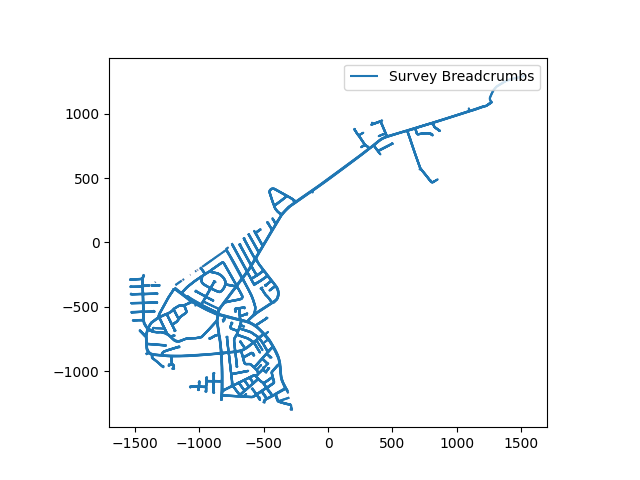

In [253]:
fig,ax = plt.subplots()
survey_gdf.plot(ax=ax, label='Survey Breadcrumbs')
survey_union_offset_gdf.plot(ax=ax, color='red', alpha=0.5, label='Street')
ax.legend()

# Generate the grid

In [254]:
# Assuming 'angle' and 'intersection_gdf' are in scope
def points_and_rotate(bottom, rot_angle):
    # Convert to Point, rotate each, and return as two tuples
    if isinstance(bottom, list) and all(isinstance(pt, tuple) and len(pt) == 2 for pt in bottom):
        rotated = [rotate(Point(pt), angle=rot_angle, origin=(0, 0)) for pt in bottom]
        if len(rotated) == 2:
            return (tuple(rotated[0].coords[0]), tuple(rotated[1].coords[0]))
    return (None, None)



In [255]:
import time
from shapely.geometry import MultiPoint
times = []
def get_max_min_points(df):
   min_x, min_y, max_x, max_y = MultiPoint(list(df['geometry'])).bounds
   return max_y - min_y

def get_nop(df):
    return df.shape[0]

start = time.perf_counter()
output_gdf = gpd.GeoDataFrame()
cumulative = 0
angle = 0
bounds = survey_union_offset_gdf.total_bounds
min_x, min_y, max_x, max_y = map(float, bounds)  # Ensure cast to float
r_x = np.sqrt(max_x**2 + max_y**2)
r_y = np.sqrt(min_x**2 + min_y**2)

# Compute number of columns safely and cast to int
num_cols = int(np.floor((2*r_x) / sampling_distance)) + 1

# Compute bar center x-positions
x_centers = np.linspace(-r_x, r_x, num=num_cols)

# For each center, form a thin rectangle
grid_lines = [
Polygon([
    (x - dx/2, r_y),
    (x + dx/2, r_y),
    (x + dx/2, -r_x),
    (x - dx/2, -r_x)
])
for x in x_centers
]
# Define the vector
vec = np.array([1,0])
ortho_vec = np.array([0,1])
grid_lines_gdf = gpd.GeoDataFrame({'geometry': grid_lines}, crs=survey_gdf.crs, geometry='geometry')
grid_lines_gdf['grid_idx'] = grid_lines_gdf.index
init_time = time.perf_counter()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    current_vec = vec   
    current_ortho_vec = ortho_vec
    for d_angle in d_angles:
            print('Processing angle: ', angle)
            # Rotate the map
            start_rotate = time.perf_counter()
            if angle == 0:
                contour_gdf = survey_union_offset_gdf.copy()
                survey_rotated_gdf = survey_gdf.copy()
            else:
                contour_gdf['geometry'] = contour_gdf['geometry'].rotate(angle=-d_angle, origin=(0,0))
                survey_rotated_gdf['geometry'] = survey_rotated_gdf['geometry'].rotate(angle=-d_angle, origin=(0,0))

            end_rotate = time.perf_counter()
            print(f'Time to Grid rotation: {end_rotate - start_rotate}')
            times.append({  
                'angle': angle,
                'Grid rotation': end_rotate - start_rotate
            })
            #Create the intersection of the grid with the survey offset
            intersection_gdf = gpd.overlay(
                grid_lines_gdf, 
                contour_gdf, 
                how='intersection', 
                keep_geom_type=False
            )    
            
            intersection_gdf = intersection_gdf.explode(index_parts=True)
            intersection_gdf.reset_index(drop=True, inplace=True)
            intersection_gdf.set_geometry('geometry', inplace=True)
            intersection_gdf.to_crs(survey_gdf.crs, inplace=True)
            end_intersection = time.perf_counter()
            print(f'Time to Grid intersection: {end_intersection - end_rotate}')

            start_bottom = time.perf_counter()
            intersection_gdf['bottom_points'] = intersection_gdf['geometry'].apply(lambda geom: get_bottom_two_points(geom,angle,rotattion = False))

            # Get the unit vector along the [1,0] direction or the rotated version
            intersection_gdf['unit_vector'] = intersection_gdf['bottom_points'].apply(safe_unit_vector)

            # Get teh angle between the unit vector and the rotated vector
            intersection_gdf['angle_measured'] = intersection_gdf['unit_vector'].apply(lambda vec: angle_between_vectors(vec,rotated_vec=[1,0]))
            intersection_gdf['angle_rotated'] = angle
            end_angle = time.perf_counter()
            print(f'Time to Angle Measurement: {end_angle - start_bottom}')
            times.append({  
                'angle': angle,
                'Angle Measurement': end_angle - start_bottom
            })

            start_right_angles = time.perf_counter()
            # Get only those lines which are aligned with the rotated vector
            right_angles = intersection_gdf[np.isclose(intersection_gdf['angle_measured'], 0, atol=tol_deg)]

            right_angles['cell_boundary'] = right_angles.apply(lambda row: get_central_line_vertical(row), axis=1)
            right_angles['cell_boundary_length'] = right_angles['cell_boundary'].apply(lambda line: line.length) - 1
            #mean_cell_boundary_length = right_angles['cell_boundary_length'].mean()
            #std_cell_boundary_length = right_angles['cell_boundary_length'].std()
            #right_angles = right_angles[np.isclose(right_angles['cell_boundary_length'], 12.7, atol=2*.9)]
            right_angles['grid_boundary'] = right_angles['geometry']
            right_angles['geometry'] = right_angles['cell_boundary']
            right_angles = right_angles.set_geometry('geometry')
            right_angles = right_angles.set_crs(utm_crs)
            right_angles['cell_idx'] = right_angles.index
            end_right_angles = time.perf_counter()
            print(f'Time to get the right angles: {end_right_angles - end_angle}')
            times.append({  
                'angle': angle,
                'Right Angles': end_right_angles - end_angle
            })


            start_survey_intersection = time.perf_counter()
            #Intersection of the boundaries with the surveys
            intersection_survey_gdf = gpd.overlay(right_angles, survey_rotated_gdf[['Order','geometry']], how='intersection', keep_geom_type=False)
            intersection_survey_gdf = intersection_survey_gdf.explode(index_parts=True)
            intersection_survey_gdf = intersection_survey_gdf[['Order','geometry']]

            intersection_survey_gdf = intersection_survey_gdf.reset_index(drop=True)
            intersection_survey_gdf = intersection_survey_gdf.set_geometry('geometry')
            intersection_survey_gdf = intersection_survey_gdf.set_crs(utm_crs)
            stop_survey_intersection = time.perf_counter()
            print(f'Time to survey intersection: {stop_survey_intersection - start_survey_intersection}')
            times.append({  
                'angle': angle,
                'Survey Intersection': stop_survey_intersection - start_survey_intersection
            })

            #Join the boundaries with the surveys intersection
            start_join = time.perf_counter()
            r = right_angles.copy()
            r['geometry'] = r['cell_boundary']
            r.drop(columns = ['cell_boundary','grid_boundary'], inplace=True)
            r = r.set_geometry('geometry')
            r = r.set_crs(utm_crs)
            joined = gpd.sjoin(r, intersection_survey_gdf, how='right', predicate='intersects')

            spread = joined.groupby('cell_idx').apply(lambda x: get_max_min_points(x))
            nop = joined.groupby('cell_idx').apply(lambda x: get_nop(x))
            spread_df = spread.reset_index()
            spread_df.rename(columns = {0:'spread'}, inplace=True)
            nop_df = nop.reset_index()
            nop_df.rename(columns = {0:'nop'}, inplace=True)
            result = pd.merge(spread_df, nop_df, on = 'cell_idx', how = 'left')
            r = pd.merge(r, result, on = 'cell_idx', how = 'left')
            stop_join = time.perf_counter()
            print(f'Time to nop and spread: {stop_join - start_join}')
            times.append({  
                'angle': angle,
                'Nop and Spread': stop_join - start_join
            })

            #filtered = right_angles[(right_angles['cell_boundary_length'] < 2*street_length)]
            output_gdf = pd.concat([output_gdf, r])
        
            #output_gdf = output_gdf[(output_gdf['spread'] < street_length + 3*std_spread) & (output_gdf['cell_boundary_length'] < street_length + 3*std_len)]
            angle = angle + d_angle
output_gdf.drop(columns = ['cell_idx'], inplace = True)


Processing angle:  0
Time to Grid rotation: 0.0031846960191614926
Time to Grid intersection: 0.37120342697016895
Time to Angle Measurement: 0.1991064769681543
Time to get the right angles: 0.14546312001766637
Time to survey intersection: 0.09812614100519568
Time to nop and spread: 0.5827976929722354
Processing angle:  -10.0
Time to Grid rotation: 0.08197446697158739
Time to Grid intersection: 0.5667207540245727
Time to Angle Measurement: 0.32962327502900735
Time to get the right angles: 0.10023473895853385
Time to survey intersection: 0.08182978496188298
Time to nop and spread: 0.3923204420134425
Processing angle:  -20.0
Time to Grid rotation: 0.10342622495954856
Time to Grid intersection: 0.5577199600520544
Time to Angle Measurement: 0.28306198900099844
Time to get the right angles: 0.07942666596500203
Time to survey intersection: 0.06318667496088892
Time to nop and spread: 0.28930078598205
Processing angle:  -30.0
Time to Grid rotation: 0.0868335550185293
Time to Grid intersection: 0

In [256]:
time_df = pd.DataFrame(times)
time_df.groupby('angle').agg({'Grid rotation':'first', 'Angle Measurement':'first', 'Right Angles':'first', 'Survey Intersection':'first', 'Nop and Spread':'first'}).reset_index()
time_df.describe()

,angle,Grid rotation,Angle Measurement,Right Angles,Survey Intersection,Nop and Spread
count,95.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,-90.000000,0.066279,0.229265,0.103892,0.064631,0.363242
std,55.062827,0.019176,0.047861,0.043604,0.015307,0.175114
min,-180.000000,0.003185,0.187575,0.032033,0.045368,0.111114
25%,-140.000000,0.060510,0.195946,0.077992,0.055338,0.266059
50%,-90.000000,0.065896,0.202354,0.100235,0.059250,0.338696
75%,-40.000000,0.072977,0.270199,0.128330,0.074770,0.459623
max,0.000000,0.103426,0.329623,0.223269,0.098126,0.845825


In [257]:
output_gdf['diff'] = (output_gdf['cell_boundary_length'] - output_gdf['spread'])/street_length
print(output_gdf.shape[0])
output_gdf_no_nan_spread = output_gdf[~output_gdf['nop'].isna()]
print(output_gdf_no_nan_spread.shape[0])
output_gdf_short = output_gdf_no_nan_spread.copy()
#output_gdf_short = output_gdf_no_nan_spread[output_gdf_no_nan_spread['cell_boundary_length'] < 2*street_length]
print(output_gdf_short.shape[0])
output_gdf_long = output_gdf_short[(output_gdf_short['diff'] >= 1) & (output_gdf_short['diff'] < 1.1)]
print(len(output_gdf_long))


2578
2534
2534
2173


In [258]:
# Group by angle_rotated, rotate geometry to -angle_rotated, and display result
from shapely import affinity

def rotate_geom_fixed(geom, angle_deg):
    """Rotate geometry -angle_deg degrees about (0,0) if supported, else return as-is."""
    # Only rotate if geometry supports it
    return affinity.rotate(geom, angle_deg, origin=(0, 0))

rotated_by_angle = []

for angle, group in output_gdf_long.groupby('angle_rotated'):
    rotated_group = group.copy()
    # Apply safe rotation for each geometry in the group (rotate to -angle_rotated) using affinity.rotate
    rotated_group['geometry'] = rotated_group.apply(
        lambda row: rotate_geom_fixed(row.geometry, row['angle_rotated']), axis=1
    )
    rotated_by_angle.append(rotated_group)

rotated_output_gdf = pd.concat(rotated_by_angle).reset_index(drop=True)

In [259]:
overlapped = gpd.sjoin(rotated_output_gdf, rotated_output_gdf, how = 'inner', predicate = 'intersects')
overlapped = overlapped[overlapped.index != overlapped.index_right].copy()
overlapped = overlapped.reset_index()

overlapped = overlapped[['index','index_right','cell_boundary_length_left']]
indx_to_remove = []

while (len(overlapped) > 0):
    overlapped_summary = overlapped.groupby('index').agg({'cell_boundary_length_left':'mean','index_right':'nunique'}).sort_values(by = 'index_right', ascending = False)
    idx_intersection = overlapped_summary['index_right'].idxmax()
    max_intersections = overlapped_summary['index_right'].max()
    if max_intersections == 1:
        idx_remove = overlapped_summary['cell_boundary_length_left'].idxmax()
        max_remove = overlapped_summary['cell_boundary_length_left'].max()
    else:
        idx_remove = idx_intersection
        max_remove = max_intersections
    overlapped = overlapped[overlapped['index'] != idx_remove]
    overlapped = overlapped[overlapped['index_right'] != idx_remove]
    indx_to_remove.append(idx_remove)
    removed_gdf = rotated_output_gdf[~(rotated_output_gdf.index.isin(indx_to_remove))]


In [260]:
geom = survey_union_offset_gdf.iloc[0].geometry

# Direct extraction of geometry numpy array is typically faster than itertuples or apply
lines = removed_gdf.geometry.values
splitters = unary_union(lines)

# Only unary_union geom.boundary once and directly pass as list with splitters
network = unary_union([geom.boundary, splitters])

# Polygonize all at once, and filter efficiently using vectorized contains (if available)
cell_polys_gen = list(polygonize(network))
# Use shapely's prepared geometries for faster contains checks
from shapely.prepared import prep
prep_geom = prep(geom)
cell_polys = [poly for poly in cell_polys_gen if prep_geom.contains(poly.representative_point())]

print(f"{len(lines)} splitters -> {len(cell_polys)} cells")
cell_gdf = gpd.GeoDataFrame({'geometry': cell_polys}, crs=survey_union_offset_gdf.crs)

2089 splitters -> 2059 cells


In [261]:
nodes = cell_gdf[['geometry']].copy()
nodes['centroid'] = nodes['geometry'].centroid
nodes.reset_index(inplace=True)

In [262]:
cell_buffer = cell_gdf.copy()
cell_buffer['geometry'] = cell_buffer['geometry'].buffer(0.5, cap_style=2)
edges_gdf = gpd.sjoin(cell_buffer, cell_buffer, how = 'left', predicate = 'intersects')
edges_gdf.rename(columns = {'index_right':'v'}, inplace = True)
edges_gdf['u'] = edges_gdf.index
edges_gdf = edges_gdf[edges_gdf['u'] < edges_gdf['v']][['geometry', 'u', 'v']]
edges_wnop_gdf = gpd.sjoin(edges_gdf, removed_gdf, how = 'left', predicate = 'intersects')

In [263]:
import networkx as nx

# Create a networkx graph
G = nx.Graph()

# Add nodes for each cell (node ids from 'u' and 'v' columns)
for idx,row in nodes.iterrows():
    G.add_node(idx)
    G.nodes[idx]['centroid'] = row['centroid']

# Add edges between neighboring cells
for _, row in edges_wnop_gdf.iterrows():
    u = row['u']
    v = row['v']
    G.add_edge(u, v)
    G[u][v]['numberOfIntersection'] = row['nop']
# Optionally display basic info about the network
print(f"Created network with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Created network with 2059 nodes and 2246 edges.


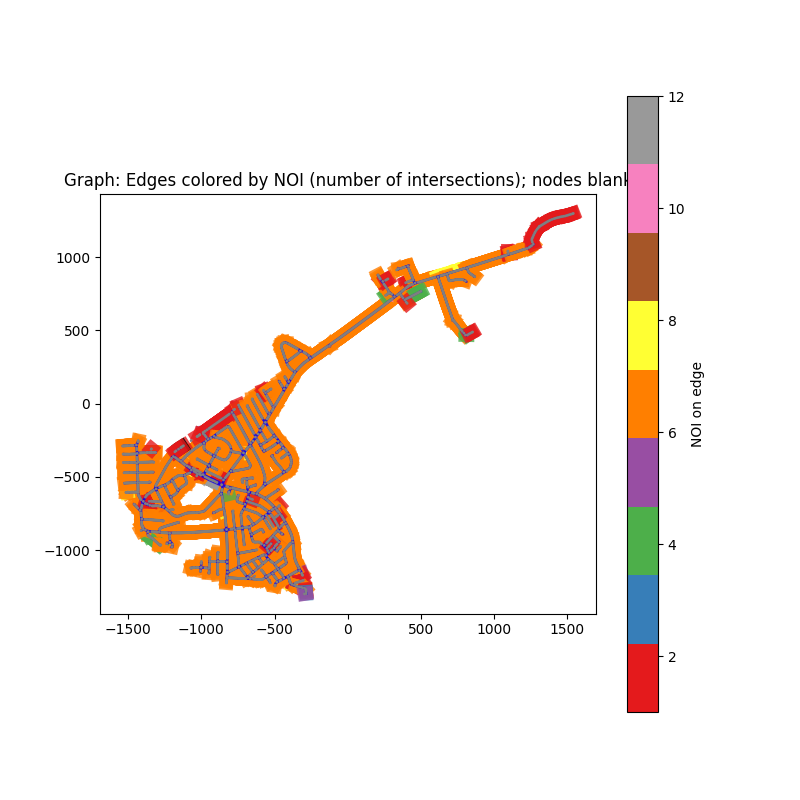

In [264]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8,8))

# Store node positions for edge plotting
node_positions = {node: (data['centroid'].x, data['centroid'].y) for node, data in G.nodes(data=True)}

# Extract all edge NOIs for colormap normalization
edge_nois = []
for u, v in G.edges():
    edge_data = G[u][v]
    noi = edge_data.get('numberOfIntersection', 0)
    edge_nois.append(noi)

# Normalize for colormap
if len(edge_nois) > 0:
    vmin = min(edge_nois)
    vmax = max(edge_nois)
else:
    vmin = vmax = 0

norm = plt.Normalize(vmin, vmax)
cmap = plt.get_cmap('Set1')

# Plot each edge with color according to its noi value
for idx, (u, v) in enumerate(G.edges()):
    x0, y0 = node_positions[u]
    x1, y1 = node_positions[v]
    noi = G[u][v].get('numberOfIntersection', 0)
    color = cmap(norm(noi))
    ax.plot([x0, x1], [y0, y1], color=color, alpha=0.8, linewidth=10, zorder=1)

# Optionally plot boundaries, etc.
# cell_gdf.boundary.plot(ax = ax, color = 'red', alpha = 0.5)
survey_gdf.plot(ax = ax, color = 'blue', alpha = 0.3)

# Draw nodes in blank (no color fill, small gray border)
node_x = [pos[0] for pos in node_positions.values()]
node_y = [pos[1] for pos in node_positions.values()]
ax.scatter(node_x, node_y, facecolor='none', edgecolor='gray', s=1, zorder=2)

# Add colorbar for edges
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label='NOI on edge')
ax.set_aspect('equal')
ax.set_title('Graph: Edges colored by NOI (number of intersections); nodes blank')
#survey_gdf.plot(ax = ax, color = 'blue', alpha = 0.3,markersize = 2, marker=2)

plt.show()
